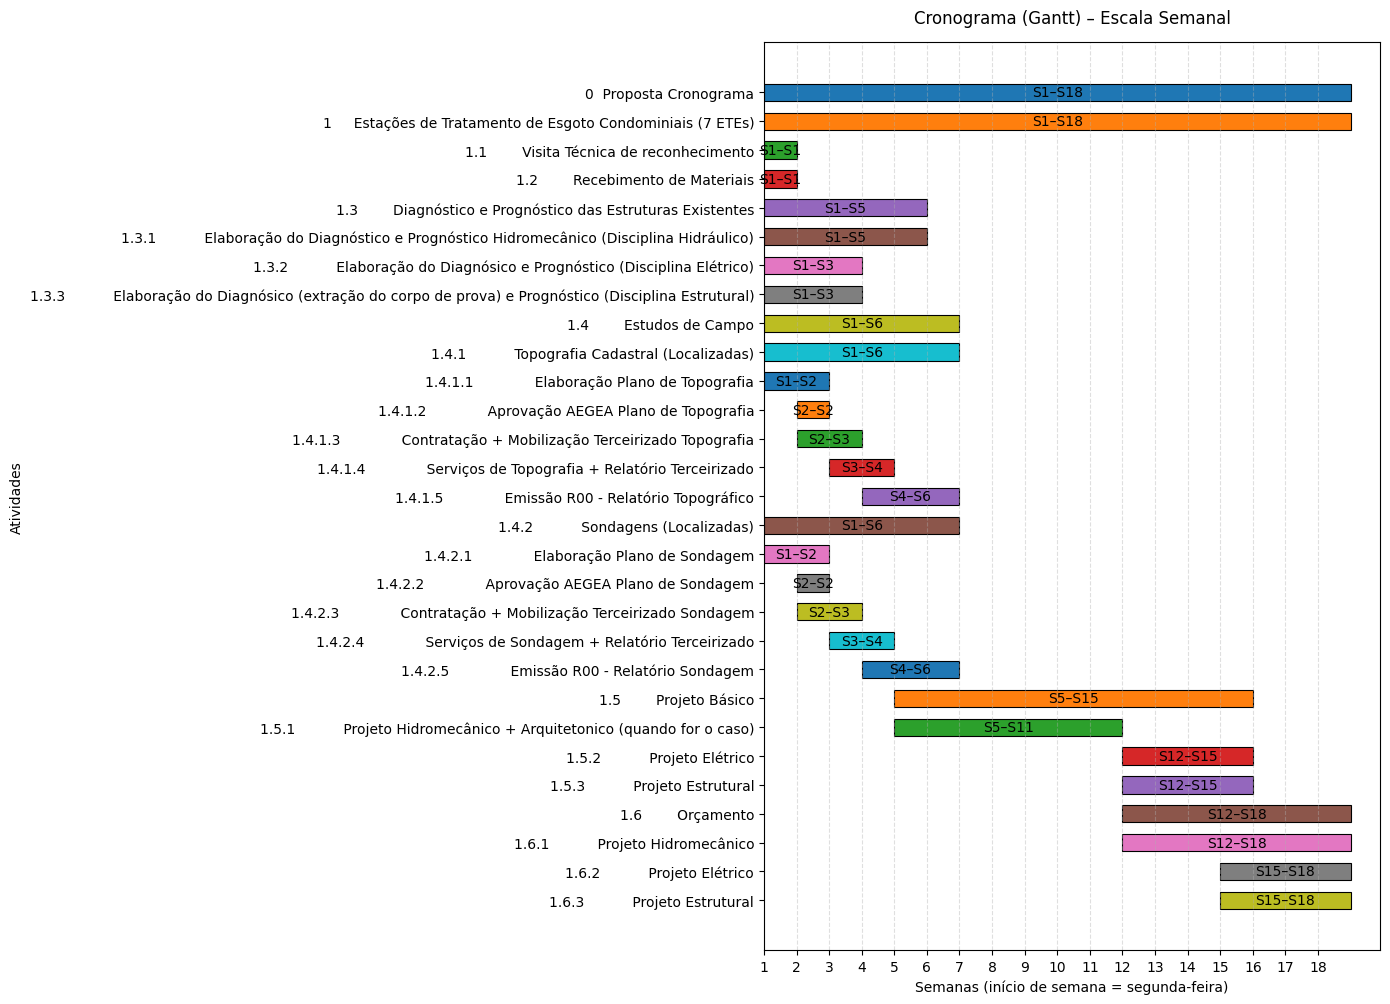

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import math

# =========================================================
# CONFIGURAÇÃO
# =========================================================
arquivo_excel = r"C:\Users\gabriel.coimbra\Downloads\EAP ETEs Condominais Camboriu.xlsx"  # <-- ajuste aqui
aba = 0                      # nome da planilha ou índice (0 = primeira)
mostrar_datas_nos_ticks = False  # True: mostra a data (dd/mm) no eixo X

# =========================================================
# FUNÇÕES AUXILIARES
# =========================================================
WEEKDAY_PT3 = {"SEG","TER","QUA","QUI","SEX","SÁB","SAB","DOM"}

def parse_br_date(texto: str) -> datetime:
    """
    Converte strings como 'Seg 13/10/25' para datetime(2025,10,13).
    Aceita variações de caixa e com/sem dia da semana.
    """
    if pd.isna(texto):
        return None
    s = str(texto).strip()
    # quebra por espaço; se o primeiro token for dia da semana PT, removemos
    partes = s.replace(",", " ").split()
    if len(partes) >= 2 and partes[0][:3].upper() in WEEKDAY_PT3:
        s = partes[1]
    else:
        # pode já vir como 13/10/25
        s = partes[0]
    # tenta %d/%m/%Y e depois %d/%m/%y
    for fmt in ("%d/%m/%Y", "%d/%m/%y"):
        try:
            return datetime.strptime(s, fmt)
        except ValueError:
            pass
    raise ValueError(f"Data inválida: {texto}")

def monday_of_week(dt: datetime) -> datetime:
    """Retorna a segunda-feira da semana da data informada."""
    return dt - timedelta(days=dt.weekday())

def semana_relativa(dt: datetime, base_monday: datetime) -> int:
    """Semana 1 = base_monday..base_monday+6; sem inclusiva; retorna 1-based."""
    dias = (dt - base_monday).days
    return dias // 7 + 1

# =========================================================
# LEITURA E PRÉ-PROCESSAMENTO
# =========================================================
df = pd.read_excel(arquivo_excel, sheet_name=aba)

# Padroniza nomes esperados
# Esperado: ['WBS','Tipo de entrega','Disciplina','Nome da Tarefa','Duração','Início','Conclusão']
renomear = {
    'WBS': 'WBS',
    'Tipo de entrega': 'TipoEntrega',
    'Disciplina': 'Disciplina',
    'Nome da Tarefa': 'Nome',
    'Duração': 'Duracao',
    'Início': 'Inicio',
    'Conclusão': 'Conclusao'
}
# tenta renomear apenas colunas existentes
df = df.rename(columns={k: v for k, v in renomear.items() if k in df.columns})

campos_necessarios = ['WBS','Nome','Inicio','Conclusao']
faltando = [c for c in campos_necessarios if c not in df.columns]
if faltando:
    raise RuntimeError(f"Faltam colunas no Excel: {faltando}. "
                       f"Esperadas ao menos: {', '.join(campos_necessarios)}")

# Converte datas
df['Inicio_dt'] = df['Inicio'].apply(parse_br_date)
df['Conclusao_dt'] = df['Conclusao'].apply(parse_br_date)

# Remove linhas sem datas válidas
df = df.dropna(subset=['Inicio_dt','Conclusao_dt']).copy()

# Define a segunda-feira base (inicio do projeto ancorado à segunda)
data_min = df['Inicio_dt'].min()
base_monday = monday_of_week(data_min)

# Calcula semanas relativas (início e fim inclusivos)
df['SemanaInicio'] = df['Inicio_dt'].apply(lambda d: semana_relativa(d, base_monday))
df['SemanaFim'] = df['Conclusao_dt'].apply(lambda d: semana_relativa(d, base_monday))
df['Semanas'] = df['SemanaFim'] - df['SemanaInicio'] + 1
df.loc[df['Semanas'] < 1, 'Semanas'] = 1  # garante ao menos 1 semana

# Opcional: ordenar por WBS numérica/lexicográfica
def chave_wbs(wbs):
    # converte "1.4.2.1" -> [1,4,2,1] para ordenar corretamente
    try:
        return [int(x) for x in str(wbs).split(".")]
    except:
        return [math.inf]
df = df.sort_values(by='WBS', key=lambda s: s.map(chave_wbs)).reset_index(drop=True)

# Rótulo que aparecerá na linha do gráfico
df['Rotulo'] = df.apply(lambda r: f"{r['WBS']}  {r['Nome']}", axis=1)

# =========================================================
# PLOT GANTT (ESCALA SEMANAL)
# =========================================================
plt.figure(figsize=(14, max(6, 0.35*len(df))))

ax = plt.gca()

for _, row in df.iterrows():
    ax.barh(
        row['Rotulo'],
        row['Semanas'],
        left=row['SemanaInicio'],
        height=0.6,           # 1 gráfico, sem cores específicas
        edgecolor='black',
        linewidth=0.8
    )
    # rótulo "Sx–Sy" no centro
    mid = row['SemanaInicio'] + row['Semanas']/2
    ax.text(mid, row['Rotulo'], f"S{int(row['SemanaInicio'])}–S{int(row['SemanaFim'])}",
            ha='center', va='center')

# ticks semanais
max_semana = int(df['SemanaFim'].max())
ax.set_xticks(range(1, max_semana + 1))

if mostrar_datas_nos_ticks:
    # Mostra "Sx (dd/mm)" no eixo X
    labels = []
    for s in range(1, max_semana + 1):
        dt = base_monday + timedelta(days=(s-1)*7)
        labels.append(f"S{s}\n({dt.strftime('%d/%m')})")
    ax.set_xticklabels(labels)

ax.set_xlabel("Semanas (início de semana = segunda-feira)")
ax.set_ylabel("Atividades")
ax.set_title("Cronograma (Gantt) – Escala Semanal", pad=14)

# grade leve no eixo X
ax.grid(axis='x', linestyle='--', alpha=0.4)

# Fase inicial no topo
ax.invert_yaxis()

plt.tight_layout()
# Para salvar: descomente a linha abaixo
plt.savefig(r"C:\Users\gabriel.coimbra\Downloads\gantt_semanal_do_excel.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# Dica: se quiser exportar a tabela com semanas calculadas:
# df[['WBS','Nome','Inicio_dt','Conclusao_dt','SemanaInicio','SemanaFim','Semanas']].to_excel("cronograma_semanas.xlsx", index=False)
